In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import multivariate_normal, poisson, norm, expon, chi2, multinomial
from scipy.optimize import curve_fit
from numpy.polynomial.polynomial import polyfit
from scipy.stats import linregress
from itertools import groupby, product
import pandas as pd
import imageio.v2 as imageio

import glob

from matplotlib.colors import PowerNorm

import datetime

In [2]:
#Definitions

####################################################################
######################## PR FUNCTIONS ##############################
####################################################################

def combined_sorted_PRs(foldername):
    # Step 2: Initialize empty lists
    all_PRs = []
    all_Seeds = []
    all_Bounds = []
    
    # Step 3: Load and append data from each file
    for file in foldername:
        PRs = np.load(file)
        all_PRs.extend(data["PRs"])
        all_Seeds.extend(data["Seeds"])
        all_Bounds.extend(data["Bounds"])
        print(f"Loaded {file}: {len(data['PRs'])} entries")
    
    # Step 4: Convert to NumPy arrays
    PRs = np.array(all_PRs)
    Seeds = np.array(all_Seeds)
    Bounds = np.array(all_Bounds)
    
    # Step 5: Save combined file
    np.savez("PRs_results_combined.npz", Data=Data, Seeds=Seeds, Bounds=Bounds)
    print(f"Saved combined results to 'PRs_results_combined.npz'")
    
    # Step 1: Get sorting indices for Seeds
    sort_idx = np.lexsort((Bounds, Seeds))
    
    # Step 2: Apply sorting to all arrays
    PRs_sorted = Data[sort_idx]
    Seeds_sorted = Seeds[sort_idx]
    Bounds_sorted = Bounds[sort_idx]

    return PRs_sorted, Seeds_sorted, Bounds_sorted

####################################################################
######################## llE FUNCTIONS #############################
####################################################################

def extended_combined_sorted_LLEs(foldername):
    # Step 2: Initialize empty lists
    all_distances = []
    all_LLEs = []
    all_activity_X1 = []
    all_activity_X2 = []
    all_Weights_Seeds = []
    all_Initialisation_Seeds = []
    all_Bounds = []
    
    # Step 3: Load and append data from each file
    for file in files:
        data = np.load(file)
        all_distances.extend(data["Distances"])
        all_LLEs.extend(data["LLEs"])
        all_activity_X1.extend(data["Activity_X1"])
        all_activity_X2.extend(data["Activity_X2"])
        all_Weights_Seeds.extend(data["Weights_Seeds"])
        all_Initialisation_Seeds.extend(data["Initialisation_Seeds"])
        all_Bounds.extend(data["Bounds"])
        print(f"Loaded {file}: {len(data['LLEs'])} entries")
    
    # Step 4: Convert to NumPy arrays
    Distances = np.array(all_distances)
    LLEs = np.array(all_LLEs)
    Activity_X1 = np.array(all_activity_X1)
    Activity_X2 = np.array(all_activity_X2)
    Weights_Seeds = np.array(all_Weights_Seeds)
    Initialisation_Seeds = np.array(all_Initialisation_Seeds)
    Bounds = np.array(all_Bounds)
    
    # Step 5: Save combined file
    np.savez("results_combined.npz", LLEs=LLEs, Distances=Distances, Activity_X1=Activity_X1, Activity_X2=Activity_X2, Weights_Seeds=Weights_Seeds, Initialisation_Seeds=Initialisation_Seeds, Bounds=Bounds)
    #np.savez("results_combined.npz", LLEs=LLEs, Seeds=Seeds, Bounds=Bounds)
    print(f"Saved combined results to 'LLEs_results_combined.npz'")
    
    # Step 1: Get sorting indices for Seeds
    sort_idx = np.lexsort((Bounds, Initialisation_Seeds, Weights_Seeds))
    
    # Step 2: Apply sorting to all arrays
    Distances_sorted = Distances[sort_idx]
    LLEs_sorted = LLEs[sort_idx]
    Activity_X1_sorted = Activity_X1[sort_idx]
    Activity_X2_sorted = Activity_X2[sort_idx]
    Weights_Seeds_sorted = Weights_Seeds[sort_idx]
    Initialisation_Seeds_sorted = Initialisation_Seeds[sort_idx]
    Bounds_sorted = Bounds[sort_idx]

    return Distances_sorted, LLEs_sorted, Activity_X1_sorted, Activity_X2_sorted, Weights_Seeds_sorted, Initialisation_Seeds_sorted, Bounds_sorted
    
def combined_sorted_LLEs(foldername):
    # Step 2: Initialize empty lists
    all_distances = []
    all_LLEs = []
    all_Seeds = []
    all_Bounds = []
    
    # Step 3: Load and append data from each file
    for file in files:
        data = np.load(file)
        all_distances.extend(data["Distances"])
        all_LLEs.extend(data["LLEs"])
        all_Seeds.extend(data["Seeds"])
        all_Bounds.extend(data["Bounds"])
        print(f"Loaded {file}: {len(data['LLEs'])} entries")
    
    # Step 4: Convert to NumPy arrays
    Distances = np.array(all_distances)
    LLEs = np.array(all_LLEs)
    Seeds = np.array(all_Seeds)
    Bounds = np.array(all_Bounds)
    
    # Step 5: Save combined file
    np.savez("results_combined.npz", LLEs=LLEs, Distances=Distances, Seeds=Seeds, Bounds=Bounds)
    #np.savez("results_combined.npz", LLEs=LLEs, Seeds=Seeds, Bounds=Bounds)
    print(f"Saved combined results to 'LLEs_results_combined.npz'")
    
    # Step 1: Get sorting indices for Seeds
    sort_idx = np.lexsort((Bounds, Seeds))
    
    # Step 2: Apply sorting to all arrays
    Distances_sorted = Distances[sort_idx]
    LLEs_sorted = LLEs[sort_idx]
    Seeds_sorted = Seeds[sort_idx]
    Bounds_sorted = Bounds[sort_idx]

    return Distances_sorted, LLEs_sorted, Seeds_sorted, Bounds_sorted

def gains_combined_sorted_LLEs(foldername):
    # Step 2: Initialize empty lists
    all_LLEs = []
    all_Gains = []
    all_Weights_Seeds = []
    all_Initialisation_Seeds = []
    all_Bounds = []
    
    # Step 3: Load and append data from each file
    for file in files:
        data = np.load(file)
        all_LLEs.extend(data["LLEs"])
        all_Gains.extend(data["Gains"])
        all_Weights_Seeds.extend(data["Weights_Seeds"])
        all_Initialisation_Seeds.extend(data["Initialisation_Seeds"])
        all_Bounds.extend(data["Bounds"])
        print(f"Loaded {file}: {len(data['LLEs'])} entries")
    
    # Step 4: Convert to NumPy arrays
    LLEs = np.array(all_LLEs)
    Gains = np.array(all_Gains)
    Weights_Seeds = np.array(all_Weights_Seeds)
    Initialisation_Seeds = np.array(all_Initialisation_Seeds)
    Bounds = np.array(all_Bounds)
    
    # Step 5: Save combined file
    np.savez("results_combined.npz", LLEs=LLEs, Gains=Gains, Weights_Seeds=Weights_Seeds, Initialisation_Seeds=Initialisation_Seeds, Bounds=Bounds)
    #np.savez("results_combined.npz", LLEs=LLEs, Seeds=Seeds, Bounds=Bounds)
    print(f"Saved combined results to 'LLEs_results_combined.npz'")
    
    # Step 1: Get sorting indices for Seeds
    sort_idx = np.lexsort((Bounds, Initialisation_Seeds, Weights_Seeds, Gains))
    
    # Step 2: Apply sorting to all arrays
    LLEs_sorted = LLEs[sort_idx]
    Gains_sorted = Gains[sort_idx]
    Weights_Seeds_sorted = Weights_Seeds[sort_idx]
    Initialisation_Seeds_sorted = Initialisation_Seeds[sort_idx]
    Bounds_sorted = Bounds[sort_idx]

    return LLEs_sorted, Gains_sorted, Weights_Seeds_sorted, Initialisation_Seeds_sorted, Bounds_sorted

def gains_combined_sorted_PRs(foldername):
    # Step 2: Initialize empty lists
    all_PRs = []
    all_Gains = []
    all_Weights_Seeds = []
    all_Initialisation_Seeds = []
    all_MSHs = []
    
    # Step 3: Load and append data from each file
    for file in files:
        data = np.load(file)
        all_PRs.extend(data["PRs"])
        all_Gains.extend(data["Gains"])
        all_Weights_Seeds.extend(data["Weights_Seeds"])
        all_Initialisation_Seeds.extend(data["Initialisation_Seeds"])
        all_MSHs.extend(data["MSHs"])
        print(f"Loaded {file}: {len(data['PRs'])} entries")
    
    # Step 4: Convert to NumPy arrays
    PRs = np.array(all_PRs)
    Gains = np.array(all_Gains)
    Weights_Seeds = np.array(all_Weights_Seeds)
    Initialisation_Seeds = np.array(all_Initialisation_Seeds)
    MSHs = np.array(all_MSHs)
    
    # Step 5: Save combined file
    np.savez("results_combined.npz", PRs=PRs, Gains=Gains, Weights_Seeds=Weights_Seeds, Initialisation_Seeds=Initialisation_Seeds, MSHs=MSHs)
    #np.savez("results_combined.npz", LLEs=LLEs, Seeds=Seeds, Bounds=Bounds)
    print(f"Saved combined results to 'PRs_results_combined.npz'")
    
    # Step 1: Get sorting indices for Seeds
    sort_idx = np.lexsort((MSHs, Initialisation_Seeds, Weights_Seeds, Gains))
    
    # Step 2: Apply sorting to all arrays
    PRs_sorted = PRs[sort_idx]
    Gains_sorted = Gains[sort_idx]
    Weights_Seeds_sorted = Weights_Seeds[sort_idx]
    Initialisation_Seeds_sorted = Initialisation_Seeds[sort_idx]
    MSHs_sorted = MSHs[sort_idx]

    return PRs_sorted, Gains_sorted, Weights_Seeds_sorted, Initialisation_Seeds_sorted, MSHs_sorted

def distance_plots(running_time, save_dir, distances_sorted, seeds_sorted, bounds_sorted):

    for index, (seed, bound) in enumerate(zip(seeds_sorted, bounds_sorted)):
        plt.figure(figsize=(10,5))
        plt.semilogy(running_time, distances_sorted[index,:])
        plt.xlabel("Time")
        plt.ylabel("log(distances between X2 and X1)")
        plt.title(f"{index}. Lyapunov divergence for heterogeneity bound {bound}, seed {seed}")
        plt.grid(True)
    
        #saving each plot
        filename = f"plot_{index}_bound{bound:.2f}_seed_{seed:.2f}.png"
        filepath = os.path.join(save_dir, filename)
        plt.savefig(filepath)
        plt.close() #closing figure to save memory
    
    plt.show()


####################################################################
######################### MUTUAL USES ##############################
####################################################################

def tanh(x):
    return (np.exp(x) - np.exp(-x))/(np.exp(x) + np.exp(-x)) 

def mu_sigma_per_bound(used_seeds, Data_sorted):

    Data_mus = []
    Data_sigmas = []
    
    
    for i in range(len(seeds)):
        Data_perseed = Data_sorted[i::len(seeds)]
        
        mu = np.mean(Data_perseed)
        sigma = np.std(Data_perseed)
    
        Data_mus.append(mu)
        Data_sigmas.append(sigma)
    
    
    one_set_of_bounds = Bounds_sorted[0:11]
    
    return Data_mus, Data_sigmas, one_set_of_bounds


In [5]:
# # Step 1: Find all result files
# files = sorted(glob.glob("python code blocks for MPI4py/PRs_different_MSHs_Gains_8-9seeds_W_and_Init_only_2s/PRs_different_MSHs_Gains_8-9seeds_W_and_Init_full_rank*.npz"))

# PRs_sorted, Gains_sorted, Weights_Seeds_sorted, Initialisation_Seeds_sorted, MSHs_sorted = gains_combined_sorted_PRs(files)

In [5]:
# Step 1: Find all result files
#files = sorted(glob.glob("C:/Users/Lenovo/Documents/B. Master Neurophysics/Stage/Presentations and reports and code/code/PR/PR data/PRs 3000N 0.2s shortened/PRs_MSHs_Gains_0-2_seeds_W_and_0-1_Init_full_rank*.npz"))

#for original range of HSM
files = sorted(glob.glob("C:/Users/Lenovo/Documents/B. Master Neurophysics/Stage/Presentations and reports and code/code/PR/PR data/All_PRs_different_MSHs_Gains_0-9seeds_W_and_Init_0.2s_shortened/PRs_different_MSHs_Gains_0-9seeds_W_and_Init_0.2s_shortened_rank*.npz"))

#for zoomed in range of HSM 0-0.1 and gain 1-3
#files = sorted(glob.glob("C:/Users/Lenovo/Documents/B. Master Neurophysics/Stage/Presentations and reports and code/code/PR/PR data/Zoomed in PRs gain 1-3 HSM 0-0.1/PRs_HSMs0-0.1_Gains1-3_W5-9_and_Init0-3/Zoomed_in_gains1-3_HSMs0-0.1_PRs_W_and_Init_rank*.npz"))


PRs_sorted, Gains_sorted, Weights_Seeds_sorted, Initialisation_Seeds_sorted, MSHs_sorted = gains_combined_sorted_PRs(files)

Loaded C:/Users/Lenovo/Documents/B. Master Neurophysics/Stage/Presentations and reports and code/code/PR/PR data/All_PRs_different_MSHs_Gains_0-9seeds_W_and_Init_0.2s_shortened\PRs_different_MSHs_Gains_0-9seeds_W_and_Init_0.2s_shortened_rank0.npz: 1836 entries
Loaded C:/Users/Lenovo/Documents/B. Master Neurophysics/Stage/Presentations and reports and code/code/PR/PR data/All_PRs_different_MSHs_Gains_0-9seeds_W_and_Init_0.2s_shortened\PRs_different_MSHs_Gains_0-9seeds_W_and_Init_0.2s_shortened_rank1.npz: 1836 entries
Loaded C:/Users/Lenovo/Documents/B. Master Neurophysics/Stage/Presentations and reports and code/code/PR/PR data/All_PRs_different_MSHs_Gains_0-9seeds_W_and_Init_0.2s_shortened\PRs_different_MSHs_Gains_0-9seeds_W_and_Init_0.2s_shortened_rank10.npz: 1836 entries
Loaded C:/Users/Lenovo/Documents/B. Master Neurophysics/Stage/Presentations and reports and code/code/PR/PR data/All_PRs_different_MSHs_Gains_0-9seeds_W_and_Init_0.2s_shortened\PRs_different_MSHs_Gains_0-9seeds_W_and

In [9]:
print(f"{Weights_Seeds_sorted[0:500]}, length of ordered seed 0 = 270 (10 (init_seeds) times 27 (MSH)), shape of Weight_Seeds_sorted: {Weights_Seeds_sorted.shape}, should be equal to n_weights_seeds = range(6,8) (shape of 2) X n_init_seeds = range(10) (shape of 10) X MSH(bounds) = np.arange(0, 5.2, 0.2) + value 10 (shape of 26 + 1= 27) X gains = np.aragne(0, 10.2, 0.2) (shape of 51) = 27540")
print(f"{Initialisation_Seeds_sorted[0:54]}, length of ordered seeds 0 = 27, shape of Weight_Seeds_sorted: {Initialisation_Seeds_sorted.shape}")
print(f" {MSHs_sorted}, length of one times all values = 27, shape of Bounds_sorted: {MSHs_sorted.shape}")
print(f"{Gains_sorted[1000:1621]}, length of 0 values = 1620 because of 27 MSHs X 10 init_seeds X 6 Weights_seeds, shape of Gains_sorted: {Gains_sorted.shape}")
print(f"{PRs_sorted[0:54]}, shape of LLEs_sorted: {PRs_sorted.shape}")

[5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 

[1.  1.2 1.4 1.6 1.8 2.  2.2 2.4 2.6 2.8 3. ]
[0.    0.001 0.002 0.003 0.004 0.005 0.006 0.007 0.008 0.009 0.01  0.011
 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02  0.021 0.022 0.023
 0.024 0.025 0.026 0.027 0.028 0.029 0.03  0.031 0.032 0.033 0.034 0.035
 0.036 0.037 0.038 0.039 0.04  0.041 0.042 0.043 0.044 0.045 0.046 0.047
 0.048 0.049 0.05  0.051 0.052 0.053 0.054 0.055 0.056 0.057 0.058 0.059
 0.06  0.061 0.062 0.063 0.064 0.065 0.066 0.067 0.068 0.069 0.07  0.071
 0.072 0.073 0.074 0.075 0.076 0.077 0.078 0.079 0.08  0.081 0.082 0.083
 0.084 0.085 0.086 0.087 0.088 0.089 0.09  0.091 0.092 0.093 0.094 0.095
 0.096 0.097 0.098 0.099 0.1  ]
[5 6 7 8 9]
[0 1 2 3]


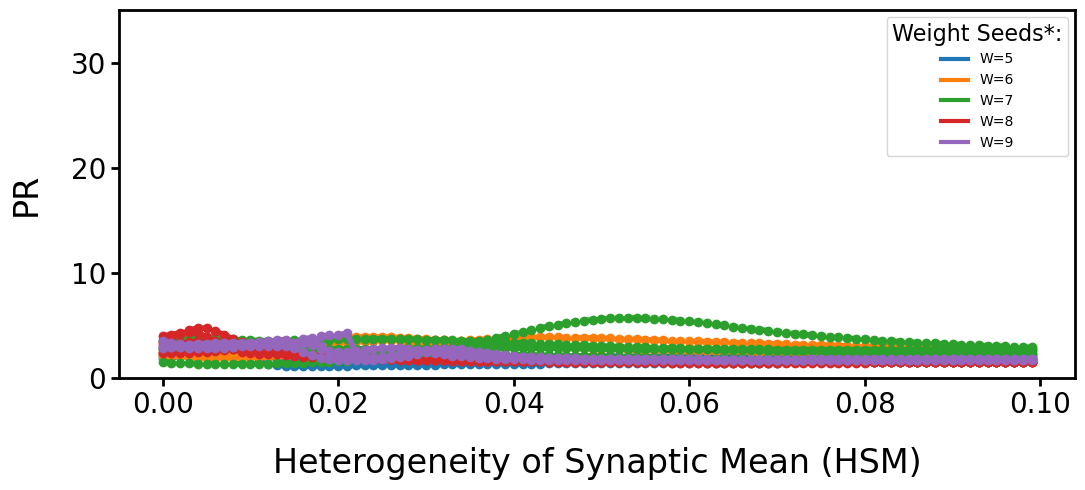

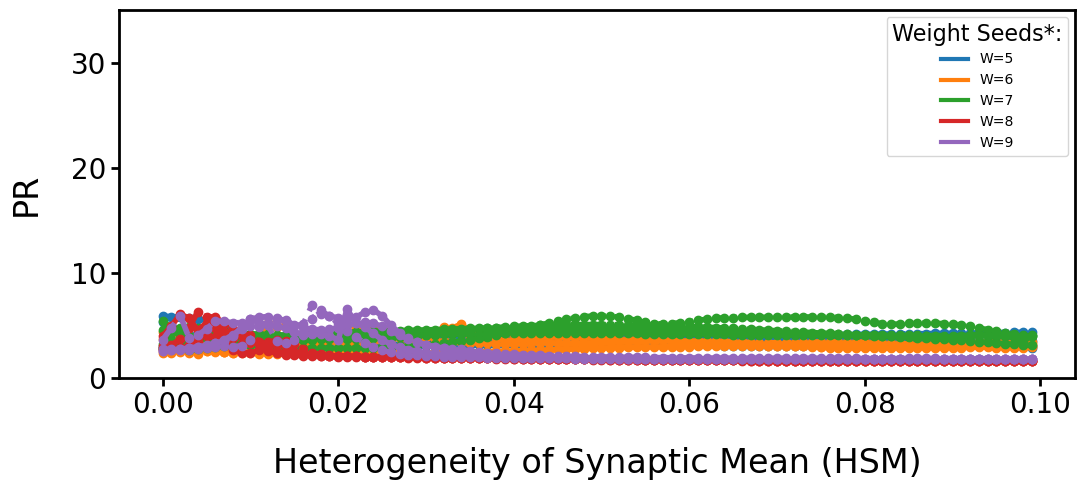

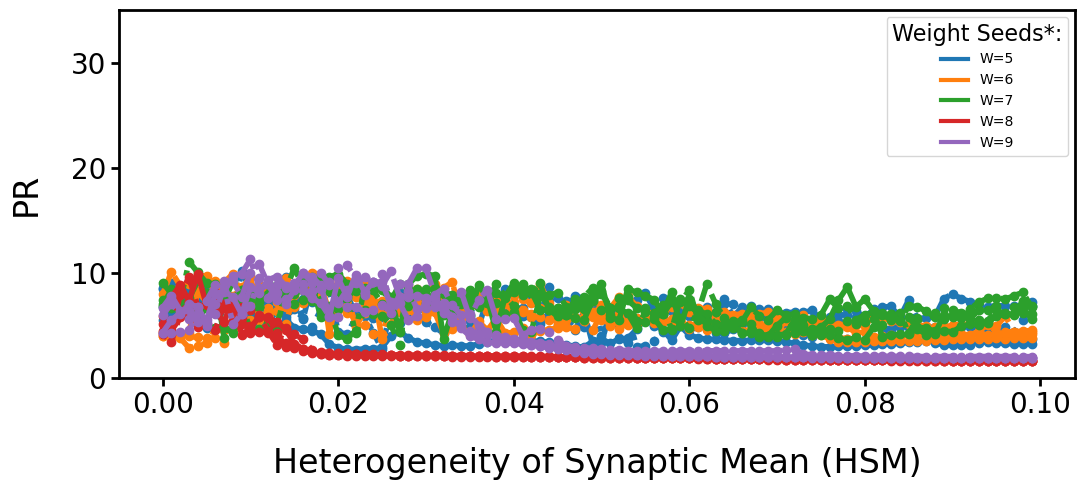

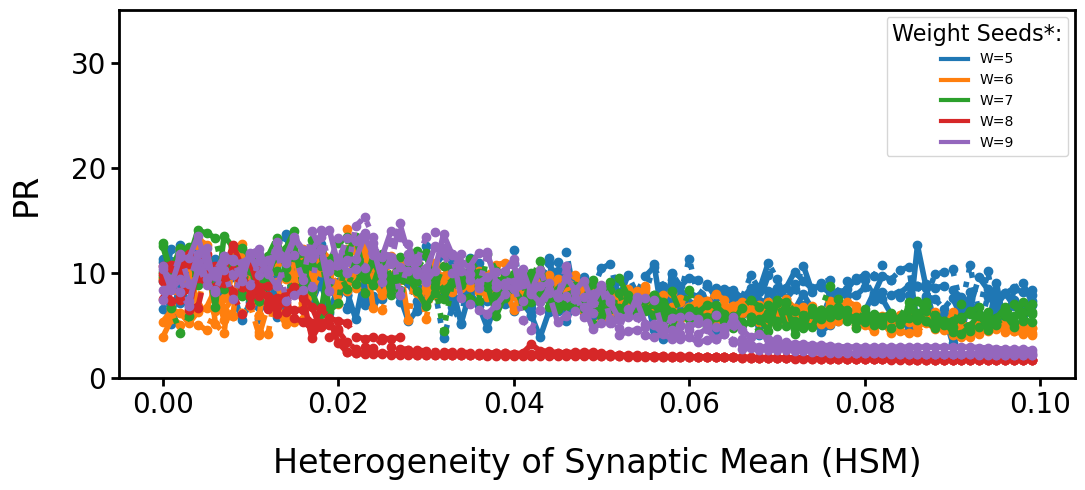

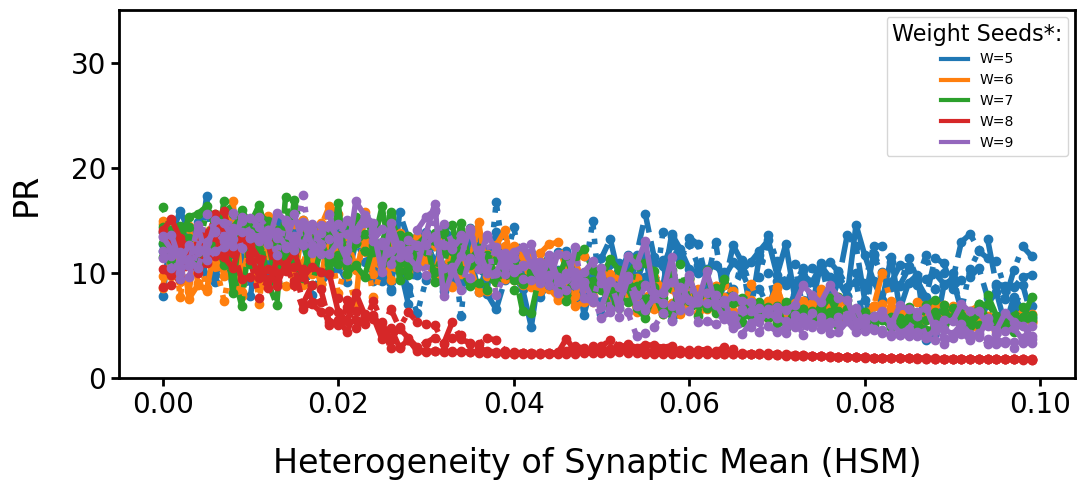

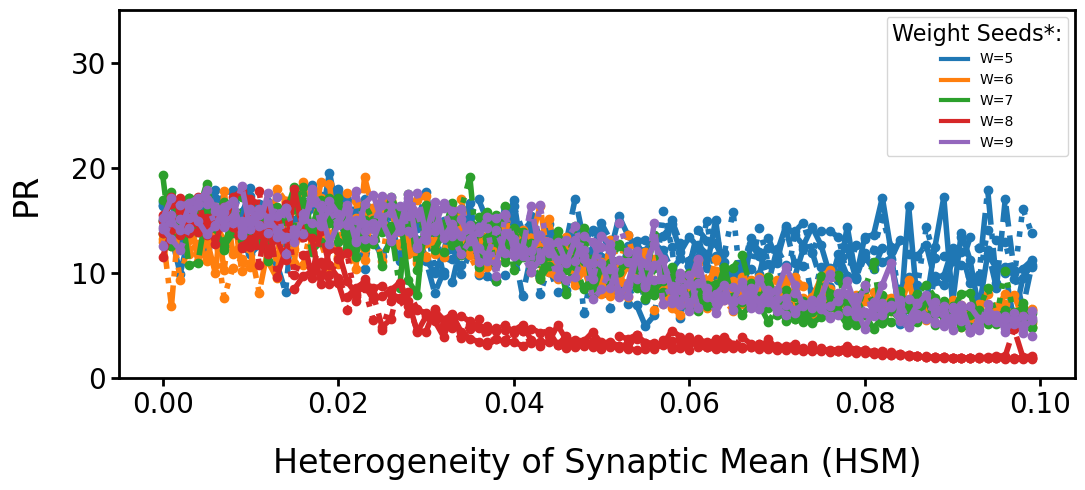

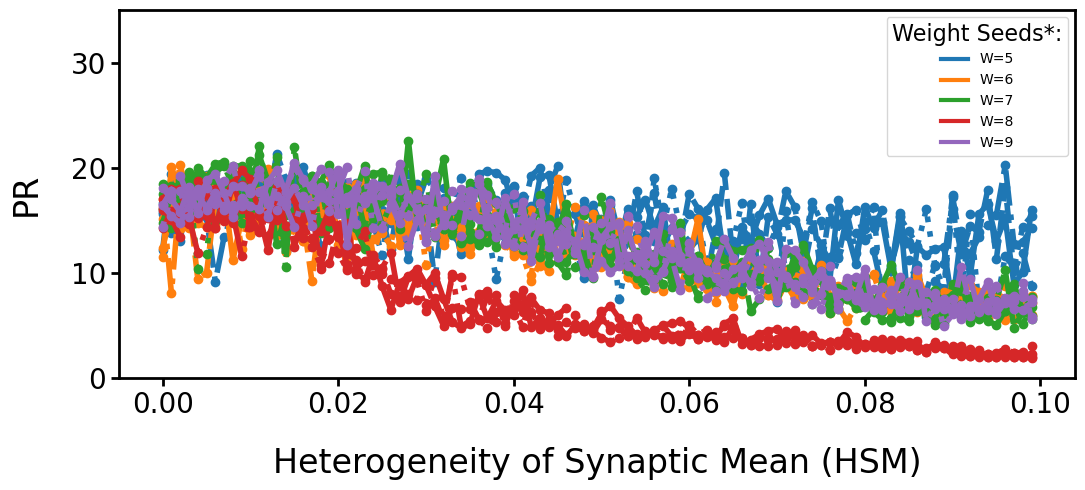

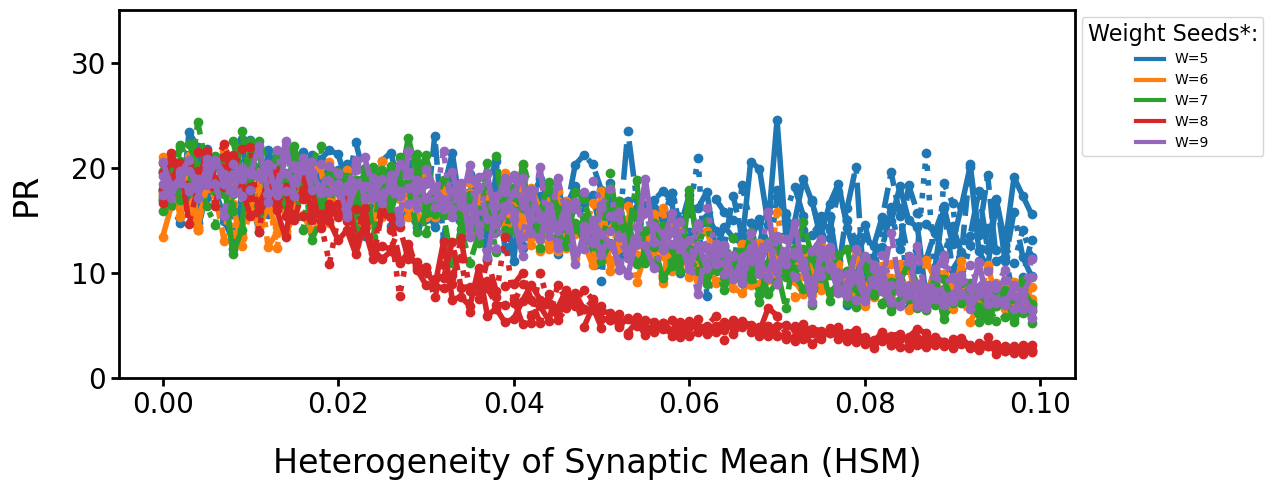

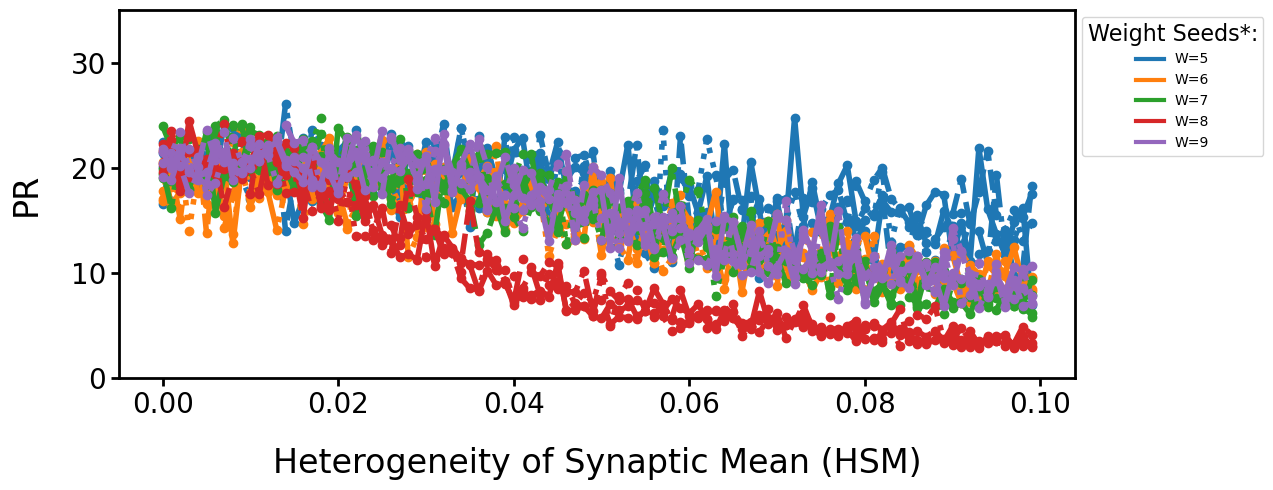

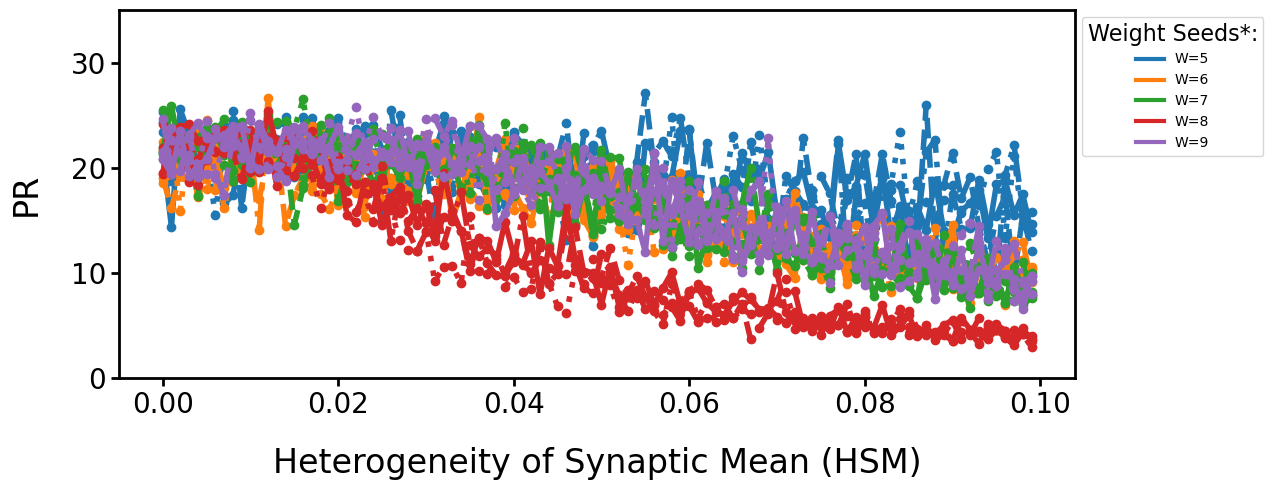

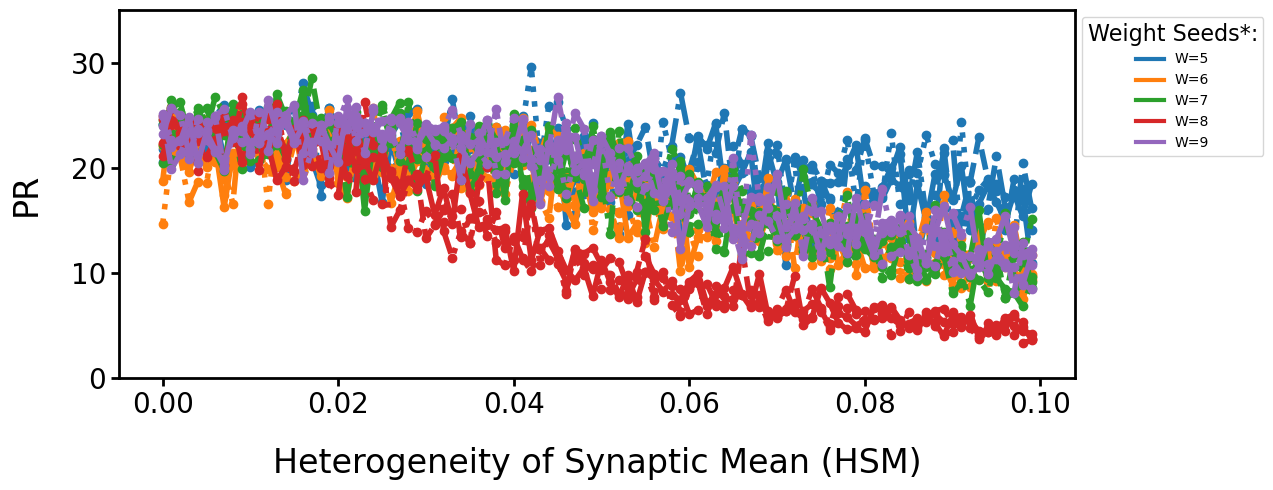

In [53]:
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 24    # x/y labels
plt.rcParams['xtick.labelsize'] = 20   # x ticks
plt.rcParams['ytick.labelsize'] = 20   # y ticks
plt.rcParams['legend.fontsize'] = 10   # legend text
plt.rcParams['figure.titlesize'] = 16  # suptitle (global title)
plt.rcParams['legend.title_fontsize'] = 16 # legend title

#tick size:
plt.rcParams['xtick.major.size'] = 6    # length of major ticks
plt.rcParams['ytick.major.size'] = 6
plt.rcParams['xtick.major.width'] = 2  # width of major ticks
plt.rcParams['ytick.major.width'] = 2



unique_Gains = np.unique(Gains_sorted)
print(unique_Gains)

unique_MSHs = np.unique(MSHs_sorted)
print(unique_MSHs)

# Colors for weight seeds


weights_seeds = np.unique(Weights_Seeds_sorted)
print(weights_seeds)

color_map = {ws: plt.cm.tab10(i % 10) for i, ws in enumerate(weights_seeds)}

# Linestyles for initialisation seeds
init_seeds_unique = np.unique(Initialisation_Seeds_sorted)
print(init_seeds_unique)

linestyle_tuple = [
    ('solid', 'solid'),
    ('dotted', 'dotted'),
    ('dashed', 'dashed'),
    ('dashdot', 'dashdot'),
    ('loosely dotted', (0, (1, 10))),
    ('densely dotted', (0, (1, 1))),
    ('loosely dashed', (0, (5, 10))),
    ('densely dashed', (0, (5, 1))),
    ('dashdotted', (0, (3, 5, 1, 5))),
    ('densely dashdotted', (0, (3, 1, 1, 1)))
]
linestyle_map = {is_: linestyle_tuple[i % len(linestyle_tuple)][1]
                 for i, is_ in enumerate(init_seeds_unique)} #not completely sure how this works, but I know what it gives qua result



# Loop over all combinations of seeds and gains
for i, gain in enumerate(unique_Gains):
    
    plt.figure(figsize=(12,5))
    for w_seed in weights_seeds:

        if w_seed in weights_seeds:
        
            for i_seed in init_seeds_unique:
                # Find indices matching this combination
                mask = (Weights_Seeds_sorted == w_seed) & (Initialisation_Seeds_sorted == i_seed) & (Gains_sorted == gain)
                if not np.any(mask):
                    continue
        
                # Extract PRs for this pair
                prs = np.array(PRs_sorted)[mask]
        
                # Sanity check: must align with unique_bounds length
                if len(prs) != len(unique_MSHs):
                    print(f"Skipping w={w_seed}, i={i_seed}, wrong length {len(prs)}")
                    continue
        
                # Plot
                plt.plot(unique_MSHs[:-1], prs[:-1],
                         color=color_map[w_seed],
                         linestyle=linestyle_map[i_seed],
                         marker='o', linewidth = 4)
                         #label=f"W={w_seed}, I={i_seed}") put this line back if you wanna see all the init seeds in the legend as well

    #Create legend handles only for weight seeds (colours)
    handles = [plt.Line2D([0], [0], color=color_map[w], lw=3, label=f"W={w}") for w in weights_seeds]

    
    
    plt.xlabel("Heterogeneity of Synaptic Mean (HSM)", labelpad=20)
    plt.ylabel("PR", labelpad=20)
    #plt.ylim(0, 50)

    plt.ylim(0,35)
    
    #plt.title(f"PRs across MSH and W and I seeds for gain of {gain:.1f}")
    #plt.grid(True)
    plt.legend(handles=handles, 
               title="Weight Seeds*:", 
               bbox_to_anchor=(1.0, 1),
               borderaxespad= 0.5,
               frameon=True,
               ncol = 1)
    plt.tight_layout()

    #for increasing the width of the plot edge line
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    
    #for increasing the width of the edge line of the colour bar
    cbar.outline.set_linewidth(2)

    filename = f"PRs Figure {i} for gain {gain:.1f}.png"
    #change path depending on 10% connectivity or not
    # filepath = os.path.join(r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\PR\PNGs PRs across MSH and W and I seeds for different gains", filename)

    filepath = os.path.join(r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\PR\PRs across HSM plots gain 1-3 HSM 0-0.1", filename)

    
    plt.subplots_adjust(right=0.9) #leaving space for legend
    plt.savefig(filepath, dpi = 300)
    #plt.savefig(filepath, dpi=300, bbox_inches='tight') #save each figure
    
    plt.show()


In [26]:
# video making



# Path where your saved figures are
folder = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\PR\PNGs PRs across MSH and W and I seeds for different gains"

# Collect all PNGs and sort them nicely
images = sorted(
    [img for img in os.listdir(folder) if img.endswith(".png")],
    key=lambda x: float(x.split("gain")[-1].replace(".png", "").strip())  # optional: sort by gain value
)

# Output video path
output_path = os.path.join(folder, "PRs_movie_1000N.mp4")

# Make the video (fps controls speed)
with imageio.get_writer(output_path,fps=5) as writer:
    for img_name in images:
        img_path = os.path.join(folder, img_name)
        writer.append_data(imageio.imread(img_path))

print("✅ Video saved at:", output_path)

✅ Video saved at: C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\PR\PNGs PRs across MSH and W and I seeds for different gains\PRs_movie_1000N.mp4


In [27]:
np.argwhere(PRs_sorted==0)

array([], shape=(0, 1), dtype=int64)

In [29]:
PRs_sorted

array([1.00090293, 1.39849057, 1.60889445, ..., 1.36794154, 1.38470918,
       1.13109648])

In [31]:
np.log(PRs_sorted)

array([0.00090252, 0.33539349, 0.47554726, ..., 0.31330709, 0.32549014,
       0.1231875 ])

In [ ]:
PRs_sorted = np.log(PRs_sorted)

44.140637471406095 0.9999999999997848


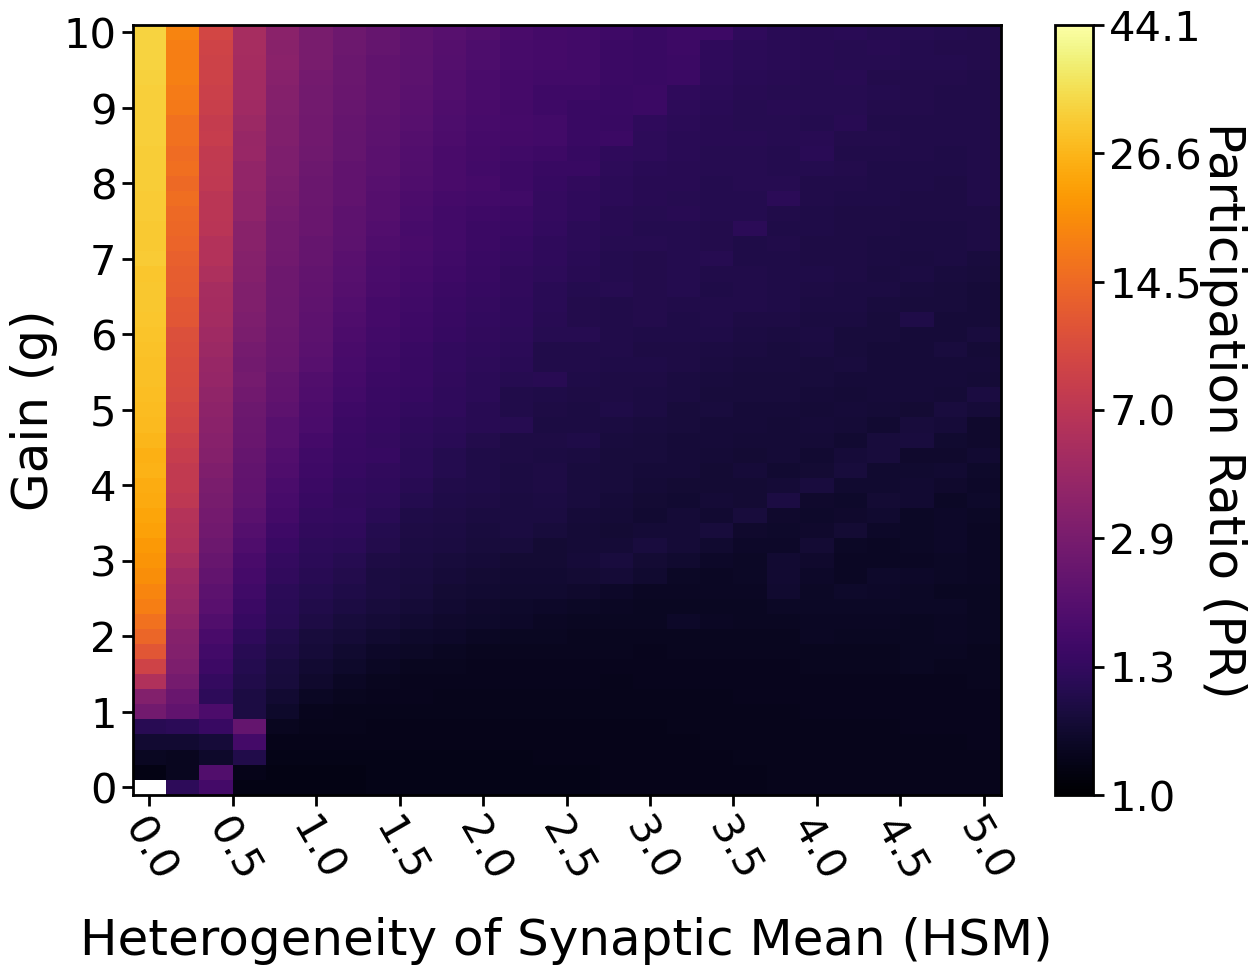

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
import pandas as pd
import datetime
import os

from matplotlib.ticker import MaxNLocator

# --- Set GLOBAL min/max for BOTH datasets ---
# GLOBAL_VMIN = 1.0  # or the minimum PR value across both datasets
# GLOBAL_VMAX = 45.1  # the maximum PR value across both datasets (from your 3000N case)

plt.rcParams['axes.titlesize'] = 30
plt.rcParams['axes.labelsize'] = 36
plt.rcParams['xtick.labelsize'] = 30
plt.rcParams['ytick.labelsize'] = 30
plt.rcParams['legend.fontsize'] = 36
plt.rcParams['figure.titlesize'] = 30
plt.rcParams['legend.title_fontsize'] = 30

#tick size:
plt.rcParams['xtick.major.size'] = 8    # length of major ticks
plt.rcParams['ytick.major.size'] = 8
plt.rcParams['xtick.major.width'] = 2  # width of major ticks
plt.rcParams['ytick.major.width'] = 2

mask = (MSHs_sorted != 10) 

df = pd.DataFrame({
    'G': Gains_sorted[mask],
    'W': Weights_Seeds_sorted[mask],
    'I': Initialisation_Seeds_sorted[mask],
    'MSH': MSHs_sorted[mask],
    'PR': PRs_sorted[mask]
})

df_mean = df.groupby(['G', 'W', 'I', 'MSH'], as_index=False)['PR'].mean()
heatmap_data = df_mean.pivot_table(index='G', columns='MSH', values='PR', aggfunc='mean')

# Set the (G=0, MSH=0) cell to NaN → will render as white
if 0 in heatmap_data.index and 0 in heatmap_data.columns:
    heatmap_data.loc[0, 0] = np.nan


# for if you do not want to compare between 1000N and 3000N
GLOBAL_VMIN = df_mean['PR'].min()
GLOBAL_VMAX = df_mean['PR'].max()

print(GLOBAL_VMAX, GLOBAL_VMIN)

plt.figure(figsize=(14,10))

gamma = 0.35

# Use GLOBAL vmin/vmax instead of data-specific min/max
norm = PowerNorm(
    gamma=gamma,
    vmin=GLOBAL_VMIN,  # Changed
    vmax=GLOBAL_VMAX   # Changed
)

cmap = plt.get_cmap('inferno').copy()
cmap.set_bad(color='white')

mesh = plt.pcolormesh(
    heatmap_data.columns,
    heatmap_data.index,
    heatmap_data.values,
    cmap=cmap,
    norm=norm
)

cbar = plt.colorbar(mesh)
cbar.set_label('Participation Ratio (PR)', rotation=270, labelpad=20)
cbar.ax.yaxis.set_label_coords(5.0, 0.5)  # Adjust position if needed


cbar.ax.minorticks_off()

n_ticks = 7
tick_positions = np.linspace(0, 1, n_ticks)

# Use GLOBAL values for tick calculation
data_min = GLOBAL_VMIN  # Changed
data_max = GLOBAL_VMAX  # Changed
gamma = gamma
tick_values = data_min + (data_max - data_min) * (tick_positions ** (1/gamma))

rounded_labels = [f"{v:.01f}" for v in tick_values]

cbar.set_ticks(tick_values)
cbar.set_ticklabels(rounded_labels)

plt.xlabel('Heterogeneity of Synaptic Mean (HSM)', labelpad=20)
plt.ylabel('Gain (g)')

#plt.title('Dimensionality for 3000N, 3 W seeds x 2 I seeds')
#plt.title('Dimensionality for 1000N, 10 W seeds x 10 I seeds')

timestamp = datetime.datetime.now().strftime("%Y-%m-%d_ %H;%M;%S")
filename = f"PR_shortened_{timestamp}"
#filename = f"PR_1000N_0.2s_shortened_Map_gain_HSM_{timestamp}.png"

filepath = os.path.join(r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\PR\PR map PNGs for Gain and HSM", filename)

#filepath = os.path.join(r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\PR\PR map 3000N", filename)

#filepath = os.path.join(r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\PR\PRs map gain 1-3 HSM 0-0.1", filename)

#for increasing the width of the plot edge line
ax = plt.gca()
ax.tick_params(axis='x', rotation=300)

#for increasing the width of the plot edge line
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(2)

ax.xaxis.set_major_locator(MaxNLocator(nbins=11))
ax.yaxis.set_major_locator(MaxNLocator(nbins=11))

#for increasing the width of the edge line of the colour bar
cbar.outline.set_linewidth(2)

plt.savefig(filepath, dpi=300)
plt.show()

<>:74: SyntaxWarning: invalid escape sequence '\s'
<>:74: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17980\1749246467.py:74: SyntaxWarning: invalid escape sequence '\s'
  cbar.set_label('standard deviation ($\sigma$) of PR', rotation=270, labelpad=20)


7.744987043071272 9.415584322910103e-14


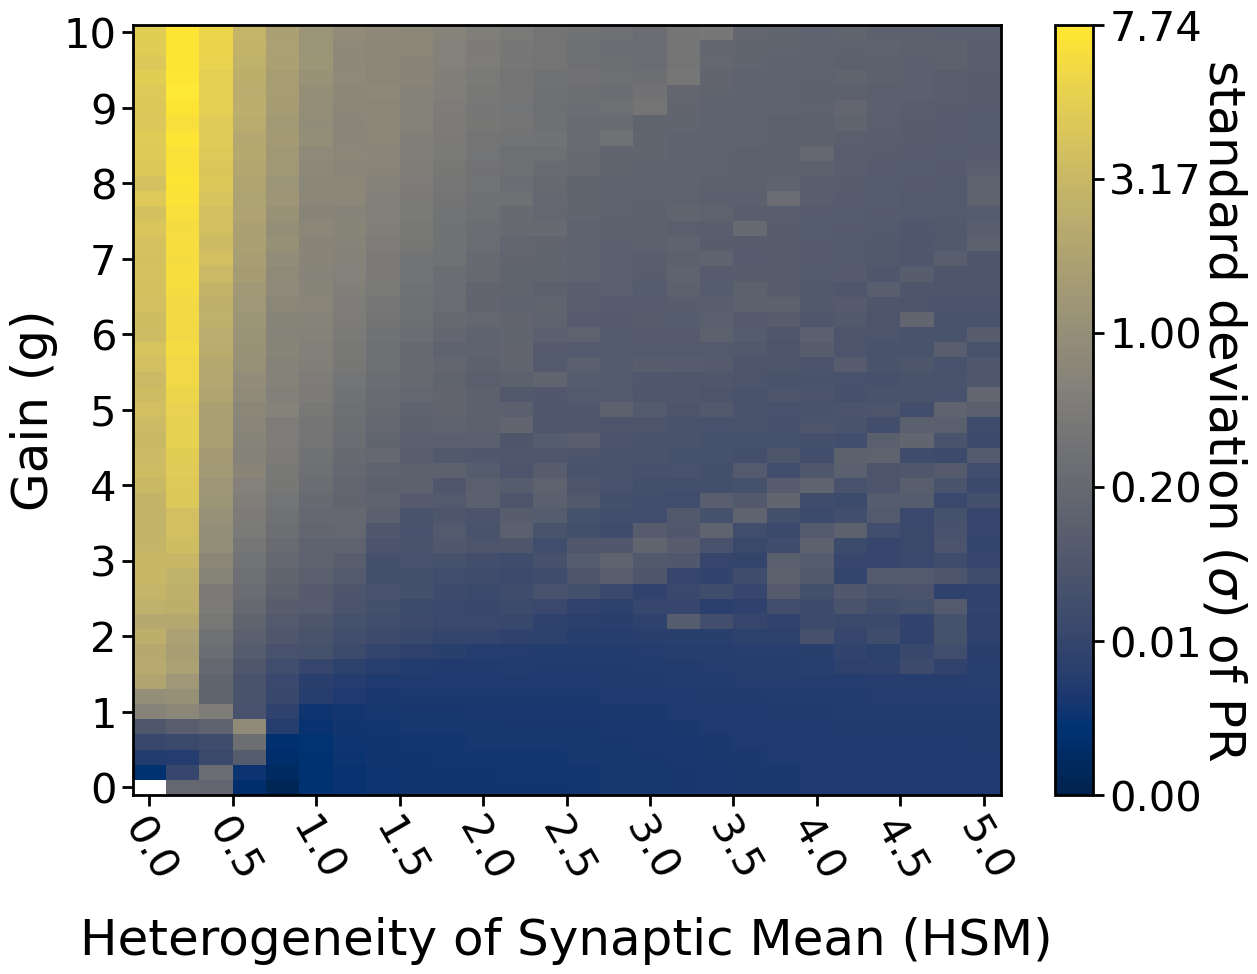

In [9]:
#Std heatmap

plt.rcParams['axes.titlesize'] = 30
plt.rcParams['axes.labelsize'] = 36
plt.rcParams['xtick.labelsize'] = 30
plt.rcParams['ytick.labelsize'] = 30
plt.rcParams['legend.fontsize'] = 36
plt.rcParams['figure.titlesize'] = 30
plt.rcParams['legend.title_fontsize'] = 30

#tick size:
plt.rcParams['xtick.major.size'] = 8    # length of major ticks
plt.rcParams['ytick.major.size'] = 8
plt.rcParams['xtick.major.width'] = 2  # width of major ticks
plt.rcParams['ytick.major.width'] = 2


mask = (MSHs_sorted != 10) 

# Put them into a DataFrame
df = pd.DataFrame({
    'G': Gains_sorted[mask],
    'W': Weights_Seeds_sorted[mask],
    'I': Initialisation_Seeds_sorted[mask],
    'MSH': MSHs_sorted[mask],
    'PR': PRs_sorted[mask]
})



# Average over W and I for each (G, MSH) combination
# (If you want to ignore W and I completely, comment the line below and uncomment the next one)
#df_mean = df.groupby(['G', 'MSH'], as_index=False)['L'].mean()
df_mean = df.groupby(['G', 'W', 'I', 'MSH'], as_index=False)['PR'].mean()
df_std = df_mean.groupby(['G', 'MSH'], as_index=False)['PR'].std()


heatmap_data = df_std.pivot_table(index='G', columns='MSH', values='PR', aggfunc='mean')


# Set the (G=0, MSH=0) cell to NaN → will render as white
if 0 in heatmap_data.index and 0 in heatmap_data.columns:
    heatmap_data.loc[0, 0] = np.nan


# for if you do not want to compare between 1000N and 3000N
GLOBAL_VMIN = df_std['PR'].min()
GLOBAL_VMAX = df_std['PR'].max()

print(GLOBAL_VMAX, GLOBAL_VMIN)

plt.figure(figsize=(14,10))

# Use GLOBAL vmin/vmax instead of data-specific min/max
norm = PowerNorm(
    gamma=0.25,
    vmin=GLOBAL_VMIN,  # Changed
    vmax=GLOBAL_VMAX   # Changed
)

cmap = plt.get_cmap('cividis').copy()
cmap.set_bad(color='white')

mesh = plt.pcolormesh(
    heatmap_data.columns,
    heatmap_data.index,
    heatmap_data.values,
    shading='auto',
    cmap=cmap,
    norm=norm
)

cbar = plt.colorbar(mesh)
cbar.set_label('standard deviation ($\sigma$) of PR', rotation=270, labelpad=20)
cbar.ax.yaxis.set_label_coords(5.0, 0.5)  # Adjust position if needed


cbar.ax.minorticks_off()

n_ticks = 6  
tick_positions = np.linspace(0, 1, n_ticks)

# Use GLOBAL values for tick calculation
data_min = GLOBAL_VMIN  # Changed
data_max = GLOBAL_VMAX  # Changed
gamma = 0.25
tick_values = data_min + (data_max - data_min) * (tick_positions ** (1/gamma))

rounded_labels = [f"{v:.02f}" for v in tick_values]

cbar.set_ticks(tick_values)
cbar.set_ticklabels(rounded_labels)



# plt.pcolormesh(heatmap_data.columns, heatmap_data.index, heatmap_data.values,
#                shading='auto', cmap='inferno')
# plt.colorbar(label='$\sigma$ of PR')
plt.xlabel('Heterogeneity of Synaptic Mean (HSM)', labelpad = 20)
plt.ylabel('Gain (g)')
# plt.title('Uncertainty of PR')
# plt.title('Heatmap of MLEs vs MSHs per Gains')

#for increasing the width of the plot edge line
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(2)

#for increasing the width of the edge line of the colour bar
cbar.outline.set_linewidth(2)

timestamp = datetime.datetime.now().strftime("%Y-%m-%d_ %H;%M;%S")
filename = f"PR_0.2s_shortened_uncertainty_{timestamp}.png"
filepath = os.path.join(r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\PR\PR map PNGs for Gain and HSM", filename)

#filepath = os.path.join(r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\PR\PRs map gain 1-3 HSM 0-0.1", filename)


#for increasing the width of the plot edge line
ax = plt.gca()
ax.tick_params(axis='x', rotation=300)
ax.xaxis.set_major_locator(MaxNLocator(nbins=11))
ax.yaxis.set_major_locator(MaxNLocator(nbins=11))

plt.savefig(filepath, dpi=300)

plt.show()

# coefficient of variation (std/mean) map

CV range: [0.0000, 0.6282]


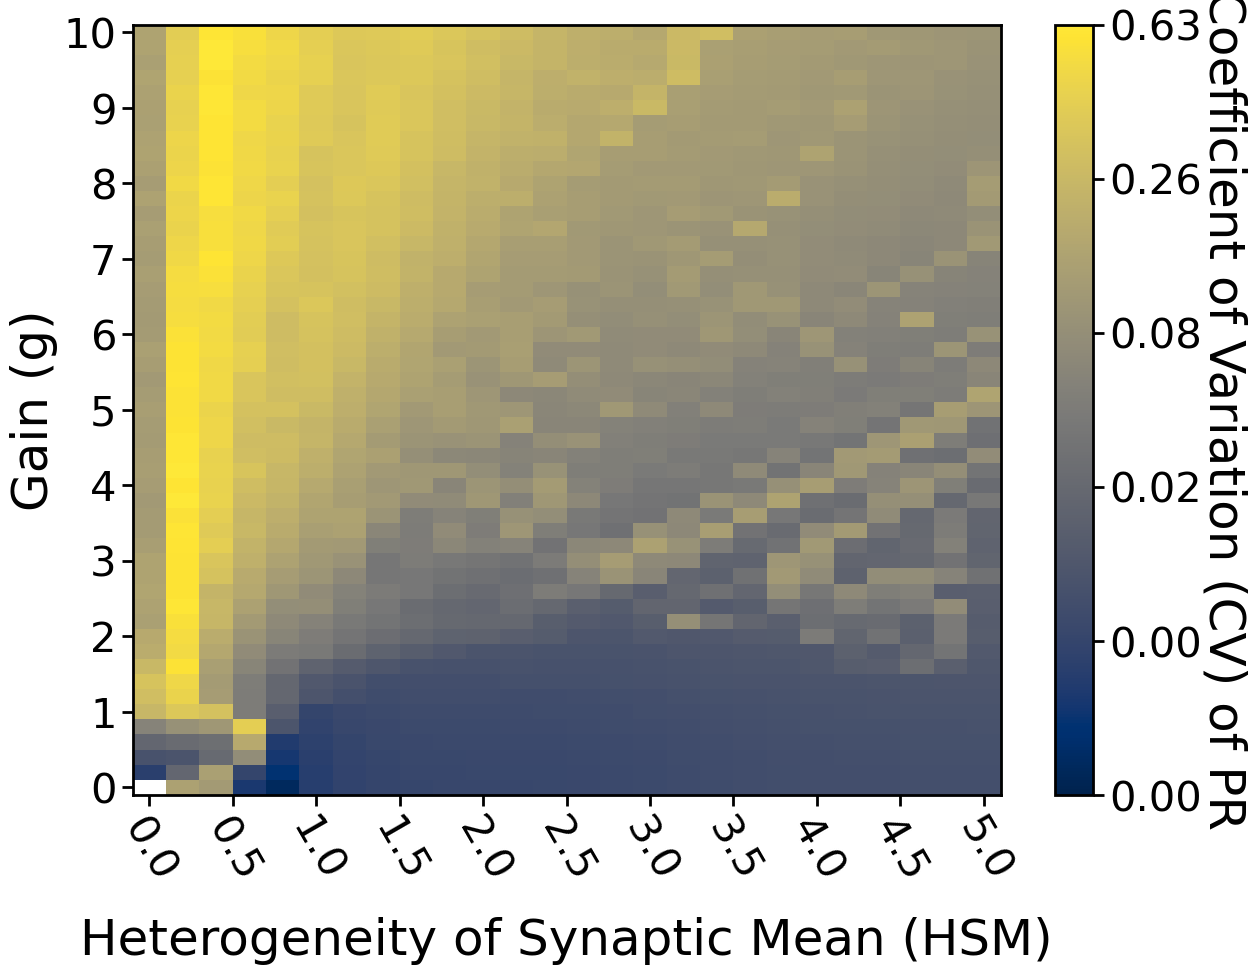

In [12]:
#CV heatmap (coefficient of variation = std / mean)
plt.rcParams['axes.titlesize'] = 30
plt.rcParams['axes.labelsize'] = 36
plt.rcParams['xtick.labelsize'] = 30
plt.rcParams['ytick.labelsize'] = 30
plt.rcParams['legend.fontsize'] = 36
plt.rcParams['figure.titlesize'] = 30
plt.rcParams['legend.title_fontsize'] = 30
plt.rcParams['xtick.major.size'] = 8
plt.rcParams['ytick.major.size'] = 8
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2

mask = (MSHs_sorted != 10)

df = pd.DataFrame({
    'G': Gains_sorted[mask],
    'W': Weights_Seeds_sorted[mask],
    'I': Initialisation_Seeds_sorted[mask],
    'MSH': MSHs_sorted[mask],
    'PR': PRs_sorted[mask]
})

# Average over W and I for each (G, MSH, W, I) combination first
df_mean = df.groupby(['G', 'W', 'I', 'MSH'], as_index=False)['PR'].mean()

# Compute std and mean across W/I seeds for each (G, MSH)
df_std  = df_mean.groupby(['G', 'MSH'], as_index=False)['PR'].std()
df_avg  = df_mean.groupby(['G', 'MSH'], as_index=False)['PR'].mean()

# Merge and compute CV = std / mean
df_cv = df_std.merge(df_avg, on=['G', 'MSH'], suffixes=('_std', '_mean'))
df_cv['CV'] = df_cv['PR_std'] / df_cv['PR_mean'].abs()  # abs() guards against negative means

heatmap_data = df_cv.pivot_table(index='G', columns='MSH', values='CV', aggfunc='mean')

# Set the (G=0, MSH=0) cell to NaN → will render as white
if 0 in heatmap_data.index and 0 in heatmap_data.columns:
    heatmap_data.loc[0, 0] = np.nan

GLOBAL_VMIN = df_cv['CV'].min()
GLOBAL_VMAX = df_cv['CV'].max()
print(f"CV range: [{GLOBAL_VMIN:.4f}, {GLOBAL_VMAX:.4f}]")

plt.figure(figsize=(14, 10))

norm = PowerNorm(
    gamma=0.25,
    vmin=GLOBAL_VMIN,
    vmax=GLOBAL_VMAX
)

cmap = plt.get_cmap('cividis').copy()
cmap.set_bad(color='white')

mesh = plt.pcolormesh(
    heatmap_data.columns,
    heatmap_data.index,
    heatmap_data.values,
    shading='auto',
    cmap=cmap,
    norm=norm
)

cbar = plt.colorbar(mesh)
cbar.set_label('Coefficient of Variation (CV) of PR', rotation=270, labelpad=20)
cbar.ax.yaxis.set_label_coords(5.0, 0.5)
cbar.ax.minorticks_off()

n_ticks = 6
tick_positions = np.linspace(0, 1, n_ticks)
gamma = 0.25
tick_values = GLOBAL_VMIN + (GLOBAL_VMAX - GLOBAL_VMIN) * (tick_positions ** (1 / gamma))
rounded_labels = [f"{v:.2f}" for v in tick_values]
cbar.set_ticks(tick_values)
cbar.set_ticklabels(rounded_labels)

plt.xlabel('Heterogeneity of Synaptic Mean (HSM)', labelpad=20)
plt.ylabel('Gain (g)')

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(2)
cbar.outline.set_linewidth(2)

ax.tick_params(axis='x', rotation=300)
ax.xaxis.set_major_locator(MaxNLocator(nbins=11))
ax.yaxis.set_major_locator(MaxNLocator(nbins=11))

timestamp = datetime.datetime.now().strftime("%Y-%m-%d_ %H;%M;%S")
filename = f"PR_0.2s_shortened_CV_{timestamp}.png"
filepath = os.path.join(r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\PR\PR map PNGs for Gain and HSM", filename)
plt.savefig(filepath, dpi=300)
plt.show()
